<a href="https://colab.research.google.com/github/Adib-Ishraq/Coding-a-LLM-from-scratch/blob/main/2_Coding_attention_mechanisms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

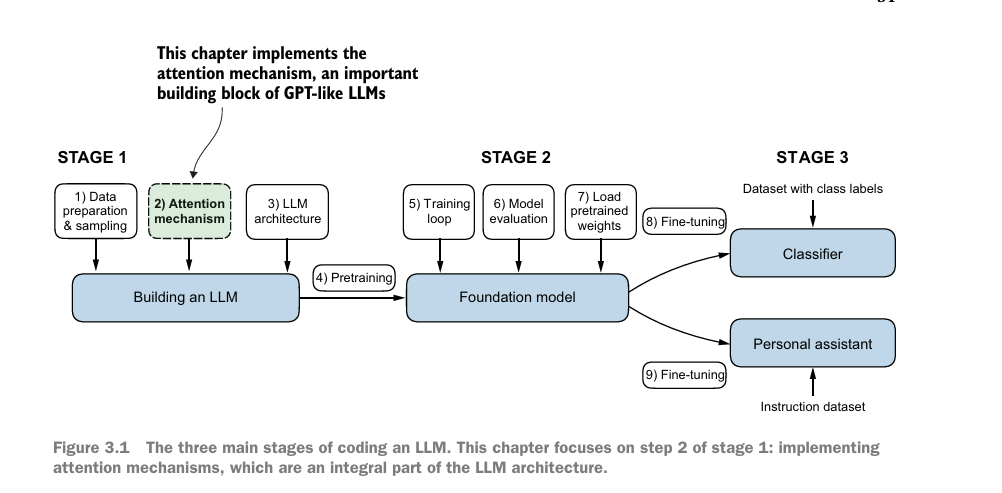

# Simplified attention

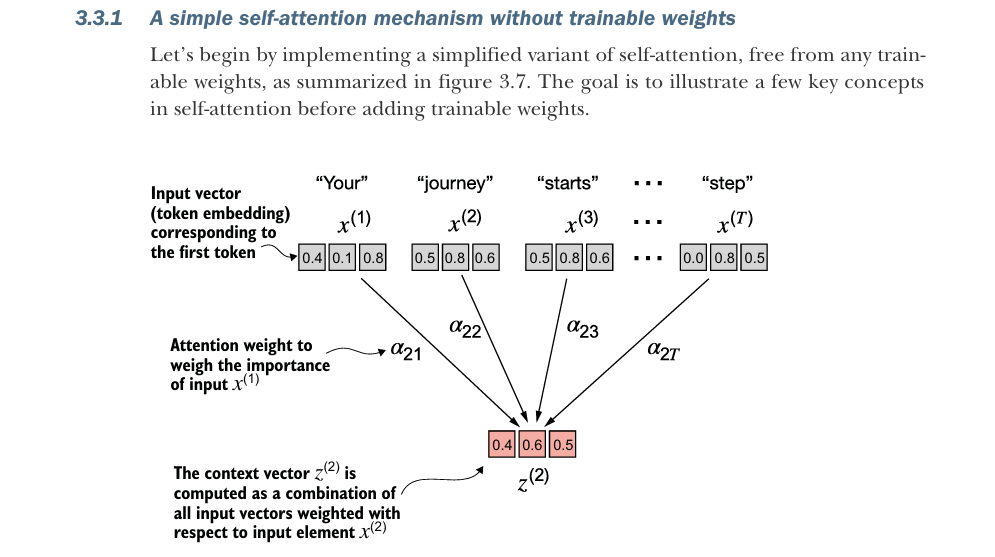

Goal is to calculate a context vector z(i) for each element x(i)

In [ ]:
import torch
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your    (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts  (x^3)
   [0.22, 0.58, 0.33], # with
   [0.77, 0.25, 0.10], # one
   [0.05, 0.80, 0.55]] # step
)

No trainable weights

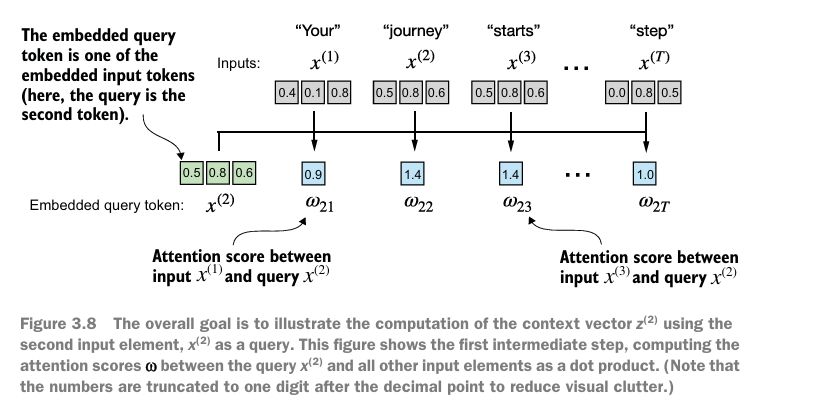

In [ ]:
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query) # dot prod of input vector and query vector
print(attn_scores_2)


tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


Now, we normalize each of the attention scores we
computed previously. The main goal behind the normalization is to obtain attention
weights that sum up to 1. This normalization is a convention that is useful for interpretation and maintaining training stability in an LLM.

In [ ]:
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("Attention weights:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weights: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


In practice, it’s more common and advisable to use the softmax function for normalization. This approach is better at managing extreme values. The following is a basic implementation of the
softmax function for normalizing the attention scores:

**why softmax?**

-> suppose, 4 elements

1, 2, 3, 400
now, normalizing:

1/406,....., 400/406

as 400 is close to one and 1 is close to zero which is not achieved if we use SUM base approach.

softmax = e**x(i)/sum helps to achieve this



In [ ]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)
attn_weights_2_naive = softmax_naive(attn_scores_2)
print("Attention weights:", attn_weights_2_naive)
print("Sum:", attn_weights_2_naive.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


pytorch softmax = e**(x(i)-max value)/sum

to cope with overflow problem and underflow for large and small values

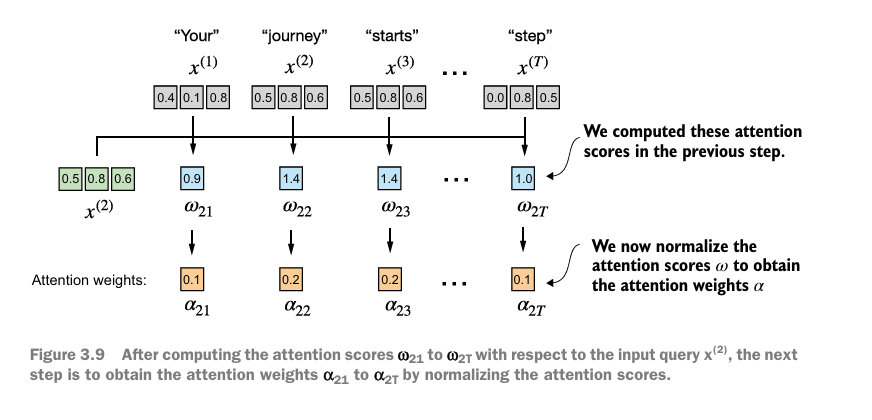

attention weights are the normalized attention scores

In [ ]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


computing context vectors, z(i) by multiplying embedded input tokens x(i) with the the corresponding attention wgts amd then summing the resultant vectors

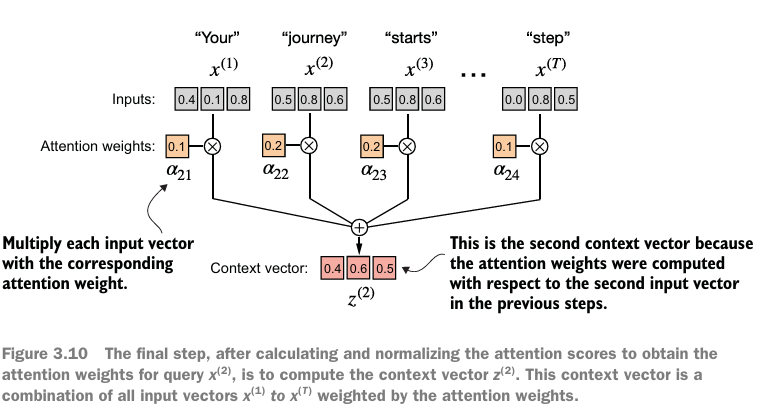

In [ ]:
query = inputs[1]
context_vec_2 = torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i]*x_i
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


now calc for all tokens

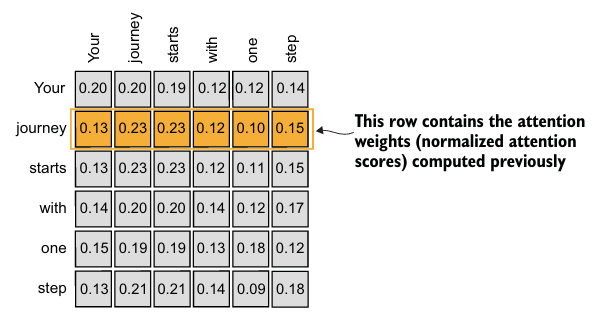

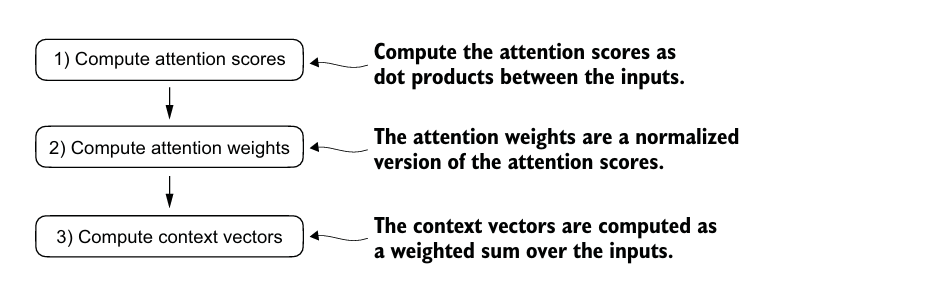

In [ ]:
attn_scores = torch.empty(6, 6)
for i, x_i in enumerate(inputs):
    for j, x_j in enumerate(inputs):
      attn_scores[i, j] = torch.dot(x_i, x_j)
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


When computing the preceding attention score tensor, we used for loops in
Python. However, for loops are generally slow, and we can achieve the same results
using matrix multiplication:

In [ ]:
attn_scores = inputs @ inputs.T
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


normalize

By setting dim=-1, we are instructing the softmax function to apply the nor
malization along the last dimension of the attn_scores tensor. If attn_scores is a
two-dimensional tensor (for example, with a shape of [rows, columns]), it will nor
malize across the columns so that the values in each row (summing over the column
dimension) sum up to 1

In [ ]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights) # each row will sum up to 1

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [ ]:
row_2_sum = sum([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
print("Row 2 sum:", row_2_sum)
print("All row sums:", attn_weights.sum(dim=-1))

Row 2 sum: 1.0
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


calc. context vector

In [ ]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


# Implementing self-attention with trainable weights

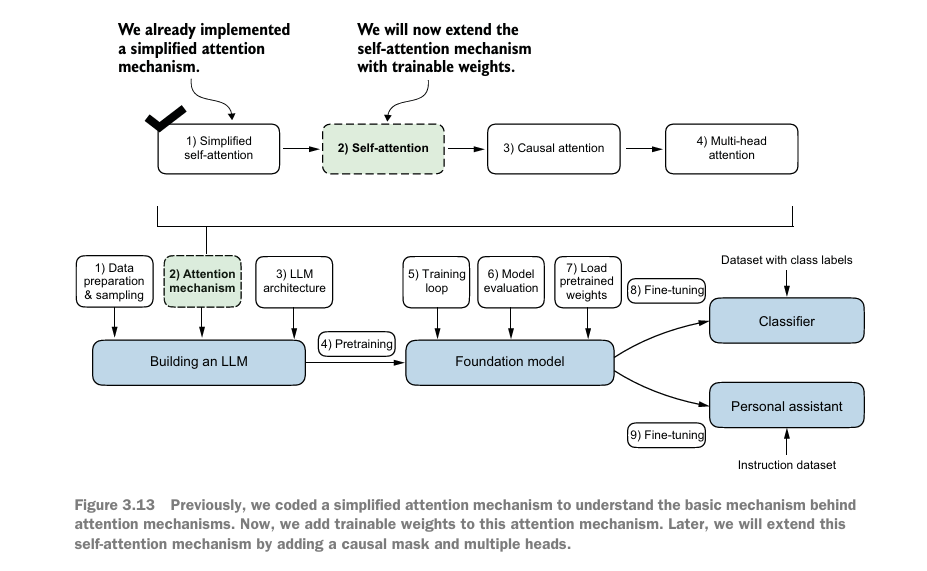

two vectors may not be sematically aligned, but they maybe close to each other in respect to the context. These trainable weight matrices are crucial so that
the model (specifically, the attention module inside the model) can learn to produce “good” context vectors.

In [ ]:
x_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

Note that in GPT-like models, the input and output dimensions are usually the same,
but to better follow the computation, we’ll use different input (d_in=3) and output
(d_out=2) dimensions here.

In [ ]:
torch.manual_seed(123)
W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

In [ ]:
print(W_query)
print(W_key)
print(W_value)

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])
Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])
Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


In [ ]:
query_2 = x_2 @ W_query # @ is matmul
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value
print(query_2)

tensor([0.4306, 1.4551])


In [ ]:
keys = inputs @ W_key
values = inputs @ W_value
queries = inputs @ W_query
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)
print("queries.shape:", queries.shape)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])
queries.shape: torch.Size([6, 2])


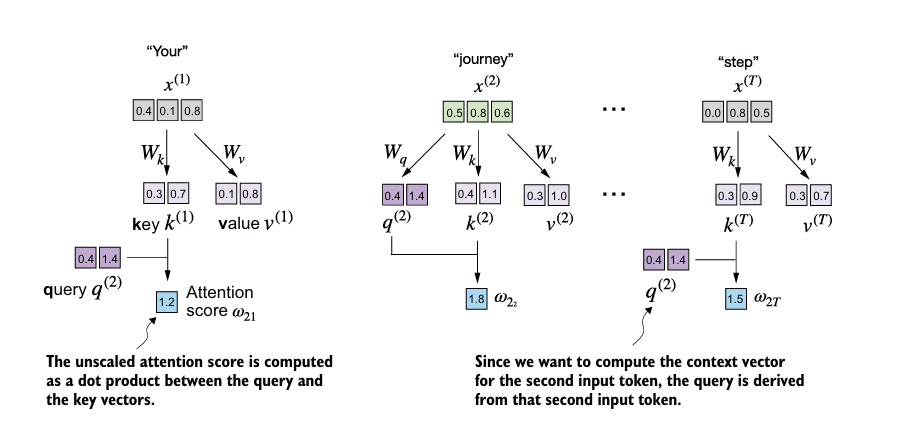

 second step is to compute the attention scores

In [ ]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)
print(attn_score_22)

tensor(1.8524)


In [ ]:
# for one query
attn_scores_2 = query_2 @ keys.T  # 1x2 dotprod 2x6
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [ ]:
# for all query
attn_scores = queries @ keys.T
print(attn_scores)

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


scale and normalize: now we scale the attention scores by dividing
them by the square root of the embedding dimension of the keys (taking the square
root is mathematically the same as exponentiating by 0.5):

In [ ]:
d_k = keys.shape[-1]
attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
print(attn_weights)

tensor([[0.1551, 0.2104, 0.2059, 0.1413, 0.1074, 0.1799],
        [0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
        [0.1503, 0.2256, 0.2192, 0.1315, 0.0914, 0.1819],
        [0.1591, 0.1994, 0.1962, 0.1477, 0.1206, 0.1769],
        [0.1610, 0.1949, 0.1923, 0.1501, 0.1265, 0.1752],
        [0.1557, 0.2092, 0.2048, 0.1419, 0.1089, 0.1794]])


 1. before softmax we do not want the values large here. so we do square root
2. why sqrt? ans: to make the variance of the dot product **stable** and not too big(variance should be close to 1)

**The rationale behind scaled-dot product attention**:
The reason for the normalization by the embedding dimension size is to improve the
training performance by avoiding small gradients. For instance, when scaling up the
embedding dimension, which is typically greater than 1,000 for GPT-like LLMs, large
dot products can result in very small gradients during backpropagation due to the
softmax function applied to them. As dot products increase, the softmax function
behaves more like a step function, resulting in gradients nearing zero. These small
gradients can drastically slow down learning or cause training to stagnate.
The scaling by the square root of the embedding dimension is the reason why this
self-attention mechanism is also called scaled-dot product attention.

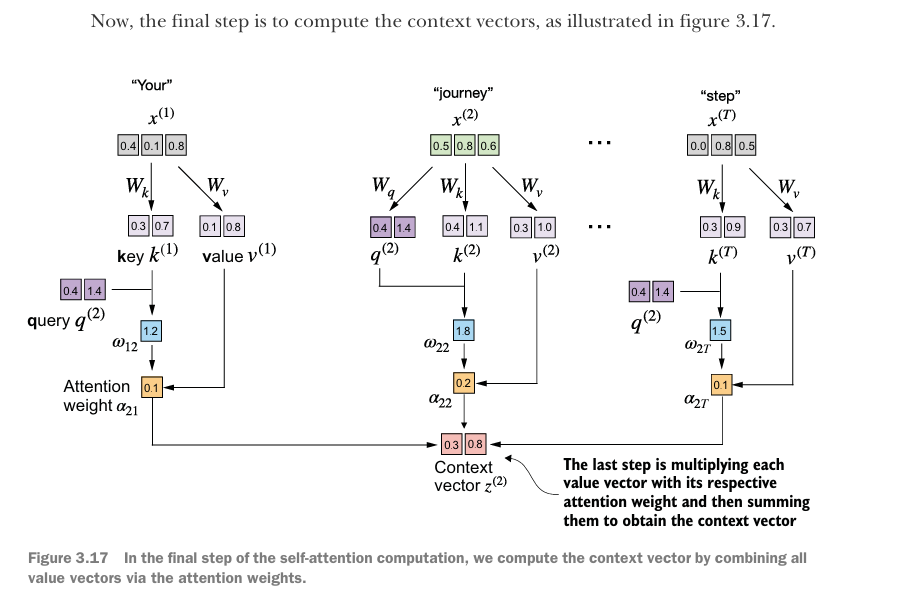

Now, the final step is to compute the context vectors

context_vec = attn wgts * values

In [ ]:
context_vec_2 = attn_weights_2 @ values #journey
print(context_vec_2)

tensor([0.3069, 0.8188])


In [ ]:
context_vec = attn_weights @ values
print(context_vec)

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]])


so all steps together:


1.   Converting input embedding into key,query and value vectors
2.   getting the Attention Scores
3.   getting the Attention weights
4.   getting the context vector




**ALL TOGETHER**: In practice, with the LLM implementation in the next chapter in mind, it is
helpful to organize this code into a Python class, as shown in the following listing.

In [ ]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        attn_scores = queries @ keys.T # omega
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        context_vec = attn_weights @ values
        return context_vec

In [ ]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


Since inputs contains six embedding vectors, this results in a matrix storing the six
context vectors

We can improve the SelfAttention_v1 implementation further by utilizing
PyTorch’s nn.Linear layers, which effectively perform matrix multiplication when
the bias units are disabled. Additionally, a significant advantage of using nn.Linear
instead of manually implementing nn.Parameter(torch.rand(...)) is that nn.Linear
has an optimized weight initialization scheme, contributing to more stable and
effective model training.

In [ ]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    def forward(self, x):
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        context_vec = attn_weights @ values
        return context_vec

In [ ]:
torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


Note that SelfAttention_v1 and SelfAttention_v2 give different outputs because
they use different initial weights for the weight matrices since nn.Linear uses a more
sophisticated weight initialization scheme.

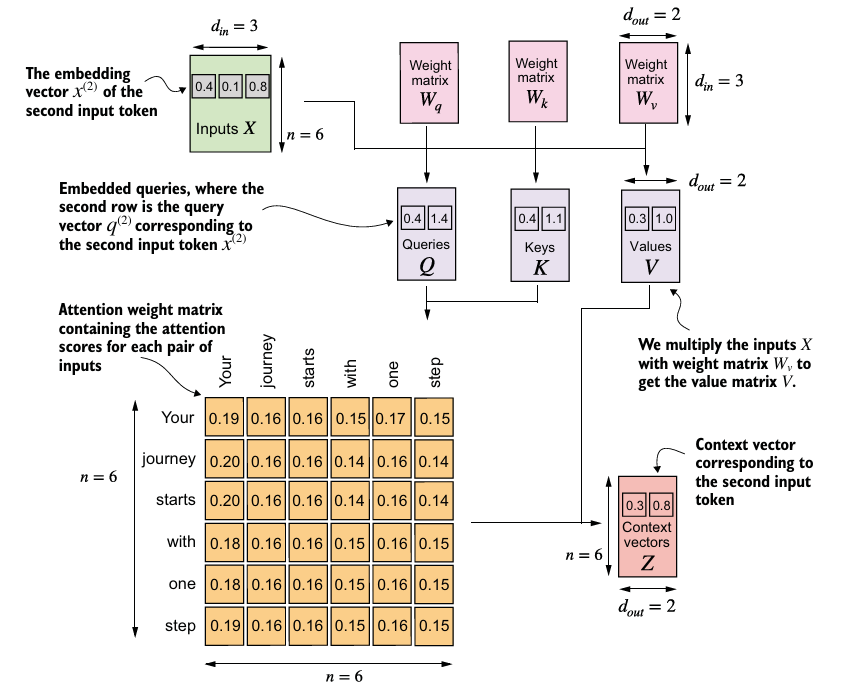

# Casual Attention



*  It restricts the model to only consider previous and current inputs in a sequence when processing any given token
* contrast to self attention mechanism which allows access to the entire input sequence at once
* for each token processed we mask out he future tokens which come after the current token in the input text

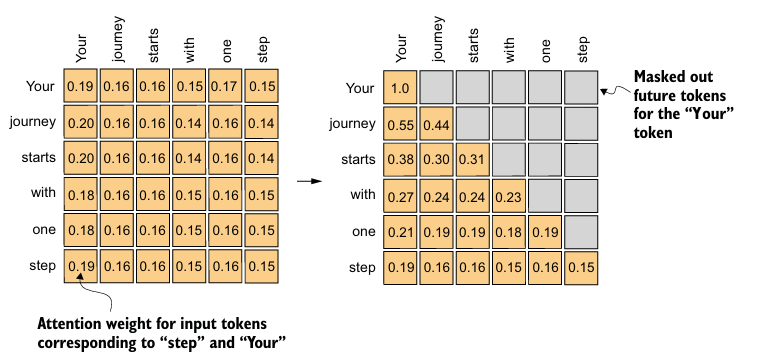

**strategy**
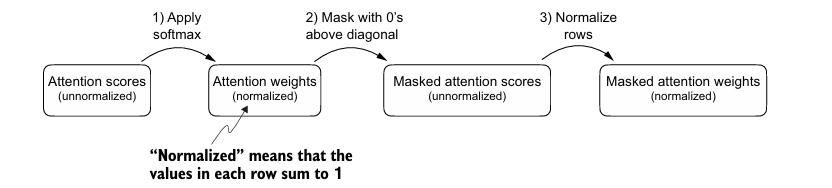

In [ ]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


generate a mask: We can implement the second step using PyTorch’s tril function to create a mask
where the values above the diagonal are zero:

In [ ]:
context_length = attn_scores.shape[0]
print(context_length)
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

6
tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [ ]:
masked_simple = attn_weights*mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


renormalize the attention weights to sum up to 1 again in each
row. We can achieve this by dividing each element in each row by the sum in each row:

In [ ]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


**ISSUE: Information leakage**


When we apply a mask and then renormalize the attention weights, it might initially
appear that information from future tokens (which we intend to mask) could still influ
ence the current token because their values are part of the softmax calculation. How
ever, the key insight is that when we renormalize the attention weights after masking, what we’re essentially doing is recalculating the softmax over a smaller subset (since
masked positions don’t contribute to the softmax value).
The mathematical elegance of softmax is that despite initially including all positions
in the denominator, after masking and renormalizing, the effect of the masked posi
tions is nullified—they don’t contribute to the softmax score in any meaningful way.
In simpler terms, after masking and renormalization, the distribution of attention
weights is as if it was calculated only among the unmasked positions to begin with.
This ensures there’s no information leakage from future (or otherwise masked)
tokens as we intended.

solution:

attention scores --> upper triangular infinity mask --> softmax

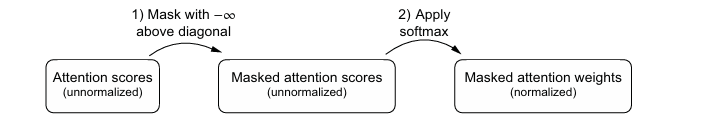

In [ ]:
print(attn_scores)

tensor([[ 0.2899,  0.0716,  0.0760, -0.0138,  0.1344, -0.0511],
        [ 0.4656,  0.1723,  0.1751,  0.0259,  0.1771,  0.0085],
        [ 0.4594,  0.1703,  0.1731,  0.0259,  0.1745,  0.0090],
        [ 0.2642,  0.1024,  0.1036,  0.0186,  0.0973,  0.0122],
        [ 0.2183,  0.0874,  0.0882,  0.0177,  0.0786,  0.0144],
        [ 0.3408,  0.1270,  0.1290,  0.0198,  0.1290,  0.0078]],
       grad_fn=<MmBackward0>)


In [ ]:
torch.triu(torch.ones(context_length, context_length), diagonal=1)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])

we will replace the 1s with -inf

In [ ]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


we have cancelled the influence of future tokens by replacing them with -inf. now we apply softmax now:

In [ ]:
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


**adding dropout**. In the transformer architecture, including models like GPT, dropout in the atten
tion mechanism is typically applied at two specific times: after calculating the atten
tion weights or after applying the attention weights to the value vectors. Here we will
apply the dropout mask after computing the attention weights

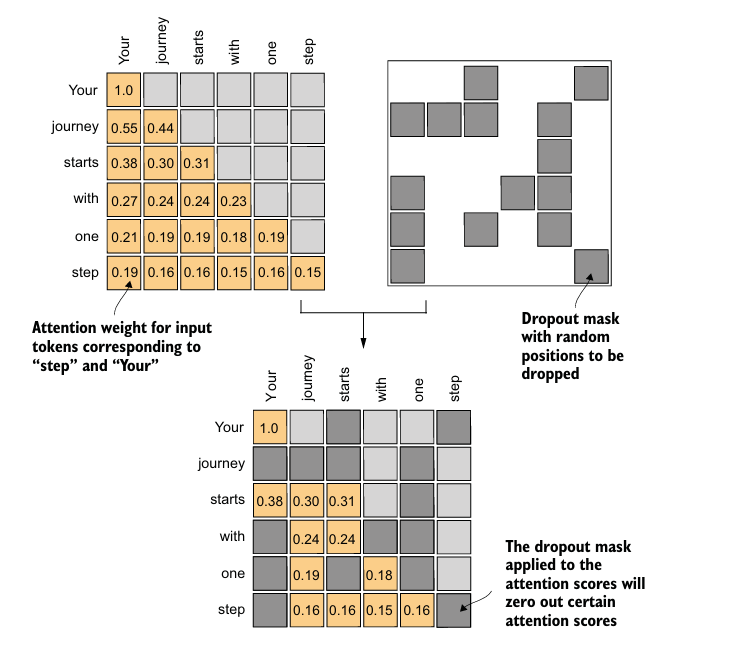

In [ ]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6, 6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


When applying dropout to an attention weight matrix with a rate of 50%, half of the
elements in the matrix are randomly set to zero. To compensate for the reduction in
active elements, the values of the remaining elements in the matrix are scaled up by a
factor of 1/0.5 = 2. This scaling is crucial to maintain the overall balance of the attention weights, ensuring that the average influence of the attention mechanism remains
consistent during both the training and inference phases.

In [ ]:
torch.manual_seed(123)
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.7599, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.4921, 0.4925, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3966, 0.0000, 0.3775, 0.0000, 0.0000],
        [0.0000, 0.3327, 0.3331, 0.3084, 0.3331, 0.0000]],
       grad_fn=<MulBackward0>)


The resulting attention weight matrix now has additional elements zeroed out and the
remaining 1s rescaled

**Implementing a compact causal attention class**

In [ ]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [ ]:
class CausalAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length,
        dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
          'mask',
          torch.triu(torch.ones(context_length, context_length),
          diagonal=1)
        )

    def forward(self, x):
          b, num_tokens, d_in = x.shape
          keys = self.W_key(x)
          queries = self.W_query(x)
          values = self.W_value(x)

          attn_scores = queries @ keys.transpose(1, 2)

          attn_scores.masked_fill_(
              self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
          attn_weights = torch.softmax(
              attn_scores / keys.shape[-1]**0.5, dim=-1
          )
          attn_weights = self.dropout(attn_weights)
          context_vec = attn_weights @ values
          return context_vec

In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)


tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])


# Multi Head Attention

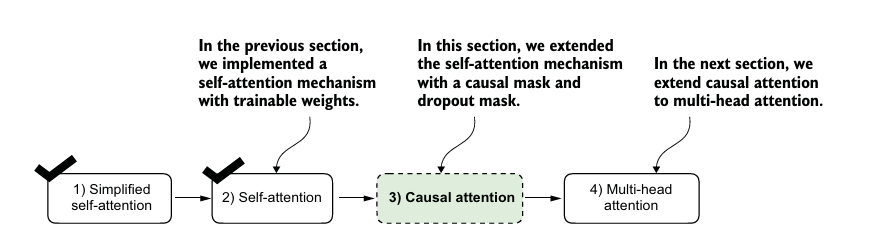

* The term “multi-head” refers to
dividing the attention mechanism into multiple
“heads,” each operating independently
* In practical terms, implementing multi-head attention involves creating multiple
instances of the self-attention mechanism , each with its own weights,
and then combining their outputs

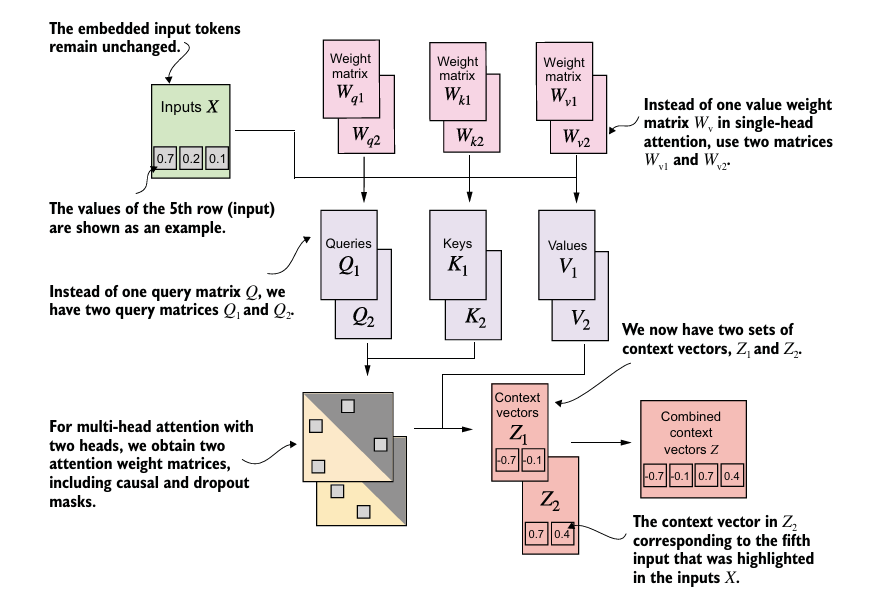

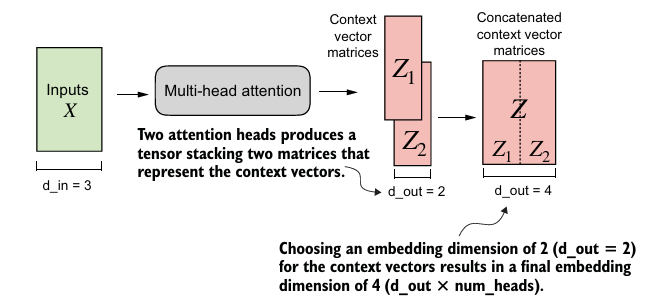

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length,
         dropout, num_heads, qkv_bias=False):
          super().__init__()
          self.heads = nn.ModuleList(
              [CausalAttention(
                  d_in, d_out, context_length, dropout, qkv_bias
              )
          for _ in range(num_heads)]
                                    )
    def forward(self, x):
          return torch.cat([head(x) for head in self.heads], dim=-1)

In [ ]:
torch.manual_seed(123)
context_length = batch.shape[1] # This is the number of tokens
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


 Implementing multi-head attention with weight splits

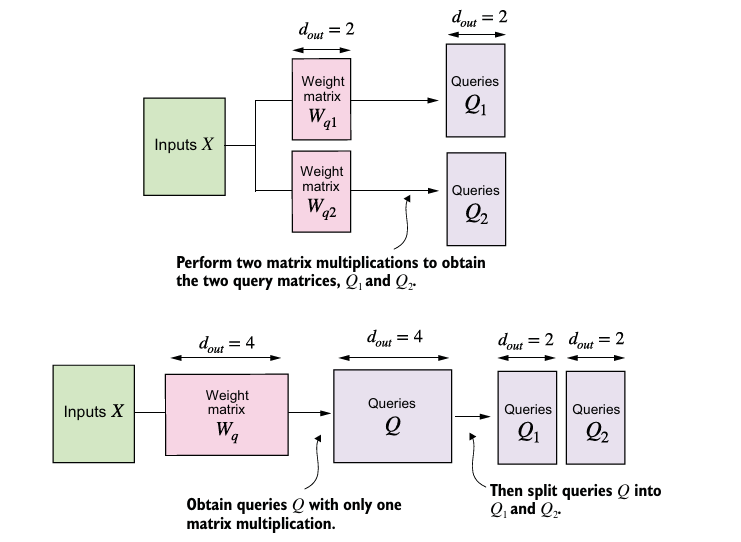

Instead of maintaining two separate classes, MultiHeadAttentionWrapper and
CausalAttention, we can combine these concepts into a single MultiHeadAttention
class. Also, in addition to merging the MultiHeadAttentionWrapper with the Causal
Attention code, we will make some other modifications to implement multi-head
attention more efficiently.
In the MultiHeadAttentionWrapper, multiple heads are implemented by creating
a list of CausalAttention objects (self.heads), each representing a separate atten
tion head. The CausalAttention class independently performs the attention mecha
nism, and the results from each head are concatenated. In contrast, the following
MultiHeadAttention class integrates the multi-head functionality within a single class.
It splits the input into multiple heads by reshaping the projected query, key, and value
tensors and then combines the results from these heads after computing attention.
Let’s take a look at the MultiHeadAttention class before we discuss it further.

1.  start with the input: (b, num_tokens, d_in)
2. decide d_out, num_heads
3. Initialize trainable weight matrices for key, query and value (Wk, Wq, Wv)
4. calculate keys, queries, values matrix (Input *Wk ....):
1x3x6 * 6x6 = 1x3x6 -> (b,num_tokens,d_out)

5. unroll last dim of keys, queries, values to include num_heads and head_dim

   head_dim = d_out/num_heads = 6/2= 3

   (b,num_tokens,d_out) --> (b,num_tokens, num_heads,head_dim)

   (1,3,6) --> (1,3,2,3)

6. Group matrices by "number of heads"

   (b,num_tokens, num_heads,head_dim) --> (b, num_heads,num_tokens, head_dim)

7. Find attention scores:

   Queries * keys.T(2,3)

   transposing num_tokens, head_dim

   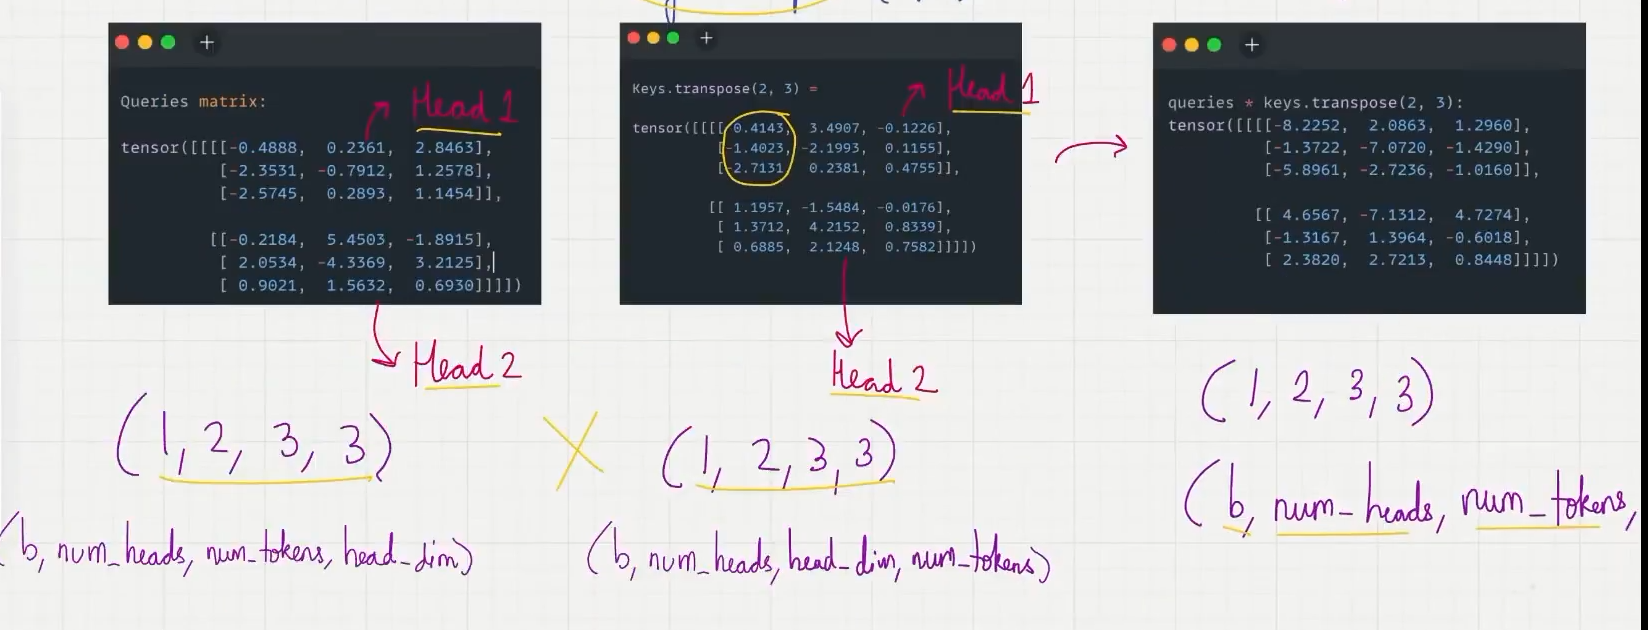



    (b, num_heads, head_dim, num_tokens) x (b, num_heads, head_dim, num_tokens) --> (b, num_heads, num_tokens num_tokens)

 8. find attention weights:

*   mask attention scores to implement casual attention
*   divide by root of head_dim = root of d_out/root of num_heads

* apply softmax

* give dropout
    
  interpretation of attention weights:

   The [The, Cat, is, sleeping]

   Cat [The, Cat, is, sleeping]

   is [The, Cat, is, sleeping]

   sleeping [The, Cat, is, sleeping]

  for example: look at 1st row: we are computing attention scores of "the" with respect to all four tokens.

9. Context Vector = **Attention weights** (b, num_heads, num_tokens num_tokens) x **Values** (b, num_heads, num_tokens, head_dim)

   ==> (b, num_heads, num_tokens, head_dim)

10. Reformat the context vectors:

    transpose(1,2) whic will give:

    (b, num_heads, num_tokens, head_dim) ==> (b,num_tokens,num_heads, head_dim)

11. Combine heads which will give
    (b, num_tokens, d_out)

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,
         context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                      diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(
            b, num_tokens, self.num_heads, self.head_dim
        )
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)
        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )
        context_vec = self.out_proj(context_vec)
        return context_vec

In [ ]:
torch.manual_seed(123)

inputs = torch.tensor([[0.43, 0.15, 0.88, 0.55, 0.87, 0.66], #row 1
                      [0.57, 0.85, 0.64, 0.22, 0.58, 0.33],
                      [0.77, 0.25, 0.10, 0.05, 0.80, 0.55]])

batch = torch.stack((inputs, inputs), dim=0)
print("batch.shape:",batch.shape)
print()
batch_size, context_length, d_in = batch.shape
d_out = 6
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)

print()
print("context_vecs.shape:", context_vecs.shape)


batch.shape: torch.Size([2, 3, 6])

tensor([[[ 0.1568, -0.0882,  0.0207,  0.0214, -0.3242, -0.2514],
         [ 0.1116, -0.0552,  0.0404, -0.0213, -0.3251, -0.2991],
         [ 0.1195, -0.0494,  0.0317, -0.0635, -0.2788, -0.2577]],

        [[ 0.1568, -0.0882,  0.0207,  0.0214, -0.3242, -0.2514],
         [ 0.1116, -0.0552,  0.0404, -0.0213, -0.3251, -0.2991],
         [ 0.1195, -0.0494,  0.0317, -0.0635, -0.2788, -0.2577]]],
       grad_fn=<ViewBackward0>)

context_vecs.shape: torch.Size([2, 3, 6])


For comparison, the smallest GPT-2 model (117 million parameters) has 12 attention heads and a context vector embedding size of 768. The largest GPT-2 model (1.5
billion parameters) has 25 attention heads and a context vector embedding size of
1,600. The embedding sizes of the token inputs and context embeddings are the same
in GPT models *(d_in = d_out)*

Summary
* Attention mechanisms transform input elements into enhanced context vector
representations that incorporate information about all inputs.
* A self-attention mechanism computes the context vector representation as a
weighted sum over the inputs.
* In a simplified attention mechanism, the attention weights are computed via
dot products.
* A dot product is a concise way of multiplying two vectors element-wise and then
summing the products.
* Matrix multiplications, while not strictly required, help us implement computations more efficiently and compactly by replacing nested for loops.
* In self-attention mechanisms used in LLMs, also called scaled-dot product
attention, we include trainable weight matrices to compute intermediate trans
formations of the inputs: queries, values, and keys.
* When working with LLMs that read and generate text from left to right, we add
a causal attention mask to prevent the LLM from accessing future tokens.
* In addition to causal attention masks to zero-out attention weights, we can add
a dropout mask to reduce overfitting in LLMs.
* The attention modules in transformer-based LLMs involve multiple instances of
causal attention, which is called multi-head attention.
* We can create a multi-head attention module by stacking multiple instances of
causal attention modules.
* A more efficient way of creating multi-head attention modules involves batched
matrix multiplications.



